# Theme Park Wait Time:  
## Temporal Dynamics & Optimization

### Authors  
Andrew Kim, Nolan Chu, Kyle Le, Leonardo Bangayan, Ryan Xavier  

---

## Project Overview: Analyzing New Ride Stabilization Using Statistical Inference

In this project, we will combine multiple wait time datasets from different theme parks—Disney, Universal, Six Flags, and Knott’s—to study how long it takes for newly opened rides to reach stable, long-term operating levels. The core idea is that when a new ride launches, its wait times are usually volatile due to hype, marketing, and irregular early-day operations. Over time, the ride should settle into a consistent pattern that reflects its true long-run popularity.

Using statistical inference, we will:

- Identify the opening period for each new ride.  
- Quantify when the ride transitions from volatile early wait times to statistically stable behavior.  
- Use measures such as variance, confidence intervals, and distributional changes to detect stabilization.  
- Compare stabilization timelines across parks to understand whether certain parks stabilize faster or slower and why.

Our goal is to build a data-driven methodology for detecting “time to stability” for new attractions, offering insights into theme park operations, guest behavior, and ride popularity dynamics.


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime




In [2]:
files = {
    "disney": "../data/wait_times_2015_2025_disney.csv",
    "sixflags": "../data/wait_times_2015_2025_sixflags.csv",
    "knotts": "../data/wait_times_2015_2025_knotts.csv",
    "universal": "../data/wait_times_2015_2025_universal.csv",
    "dca": "../data/wait_times_2015_2024_DCA.csv"
}

dfs = {k: pd.read_csv(v) for k, v in files.items()}


In [3]:
for name, df in dfs.items():
    print(f"\n=== {name.upper()} ===")
    display(df.head())
    display(df.describe(include='all'))



=== DISNEY ===


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2015-01-01,Space Mountain,50.0,96.0
1,2015-01-01,Indiana Jones™ Adventure,48.0,91.0
2,2015-01-01,Peter Pan's Flight,42.0,50.0
3,2015-01-01,Alice in Wonderland,37.0,50.0
4,2015-01-01,Roger Rabbit's Car Toon Spin,34.0,61.0


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
count,174682,174682,85281.000000,84902.000000
unique,3133,167,NaN,NaN
top,2015-07-04,Space Mountain,NaN,NaN
freq,94,3133,NaN,NaN
mean,NaN,NaN,21.007294,36.195025
std,NaN,NaN,14.859333,26.973308
min,NaN,NaN,0.000000,5.000000
25%,NaN,NaN,10.000000,15.000000
50%,NaN,NaN,18.000000,30.000000
75%,NaN,NaN,29.000000,50.000000



=== SIXFLAGS ===


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2017-01-01,Santa's Wild Sleigh Ride,100.0,100.0
1,2017-01-01,X2,70.0,70.0
2,2017-01-01,Full Throttle,68.0,70.0
3,2017-01-01,Twisted Colossus,52.0,55.0
4,2017-01-01,Tatsu,51.0,55.0


...

,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2018-07-19,TRANSFORMERS™: The Ride-3D,61.0,85.0
1,2018-07-19,Jurassic World — The Ride,56.0,80.0
2,2018-07-19,The Simpsons Ride™,49.0,60.0
3,2018-07-19,Harry Potter and the Forbidden Journey™,47.0,95.0
4,2018-07-19,Revenge of the Mummy – The Ride,47.0,65.0


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
count,30347,30347,22480.000000,22454.000000
unique,1959,66,NaN,NaN
top,2024-12-31,TRANSFORMERS™: The Ride-3D,NaN,NaN
freq,23,1959,NaN,NaN
mean,NaN,NaN,30.675089,53.061593
std,NaN,NaN,22.383210,35.372396
min,NaN,NaN,0.000000,5.000000
25%,NaN,NaN,15.000000,30.000000
50%,NaN,NaN,25.000000,45.000000
75%,NaN,NaN,40.000000,70.000000



=== DCA ===


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2015-01-01,Radiator Springs Racers,82.0,166.0
1,2015-01-01,Toy Story Midway Mania!,52.0,75.0
2,2015-01-01,Pixar Pal-A-Round - Swinging,38.0,80.0
3,2015-01-01,"Monsters, Inc. Mike & Sulley to the Rescue!",28.0,60.0
4,2015-01-01,For the First Time in Forever: A Frozen Sing-A...,26.0,27.0


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
count,116743,116743,53752.000000,53539.000000
unique,3132,131,NaN,NaN
top,2015-12-22,Radiator Springs Racers,NaN,NaN
freq,66,3132,NaN,NaN
mean,NaN,NaN,21.705778,38.103887
std,NaN,NaN,20.389758,35.530112
min,NaN,NaN,0.000000,3.000000
25%,NaN,NaN,6.000000,10.000000
50%,NaN,NaN,15.000000,30.000000
75%,NaN,NaN,30.000000,55.000000


In [4]:
# unpack dictionary into separate dataframes
disney_df    = dfs["disney"].copy()
sixflags_df  = dfs["sixflags"].copy()
knotts_df    = dfs["knotts"].copy()
universal_df = dfs["universal"].copy()
dca_df       = dfs["dca"].copy()

### Initial Data Observation

Based on the preview of the data (`head()`), it is clear that not every entry in the dataset corresponds to an actual ride. Some rows reflect non-ride entities such as parades, shows, general park areas, or improperly labeled entries. Because of this, we will need to manually clean the datasets to ensure that only valid ride wait times are included in our analysis. This step is essential for producing accurate statistical results when examining ride stabilization patterns.


In [5]:
# Disneyland
print("\n=== UNIQUE RIDES: DISNEYLAND ===")
disney_rides = sorted(disney_df["Ride"].dropna().unique())
print(f"Number of unique rides: {len(disney_rides)}")
print(disney_rides)

# DCA
print("\n=== UNIQUE RIDES: DCA ===")
dca_rides = sorted(dca_df["Ride"].dropna().unique())
print(f"Number of unique rides: {len(dca_rides)}")
print(dca_rides)

# Universal
print("\n=== UNIQUE RIDES: UNIVERSAL ===")
universal_rides = sorted(universal_df["Ride"].dropna().unique())
print(f"Number of unique rides: {len(universal_rides)}")
print(universal_rides)

# Knotts
print("\n=== UNIQUE RIDES: KNOTTS ===")
knotts_rides = sorted(knotts_df["Ride"].dropna().unique())
print(f"Number of unique rides: {len(knotts_rides)}")
print(knotts_rides)

# Six Flags
print("\n=== UNIQUE RIDES: SIX FLAGS ===")
sixflags_rides = sorted(sixflags_df["Ride"].dropna().unique())
print(f"Number of unique rides: {len(sixflags_rides)}")
print(sixflags_rides)







=== UNIQUE RIDES: DISNEYLAND ===
Number of unique rides: 167
['"Ant-Man and The Wasp" Sneak Peek at Tomorrowland Theater', '"Fantasy In The Sky"*', '"Minnie & Friends - Breakfast in the Park"', '"it\'s a small world" Holiday', 'A Christmas Fantasy Parade', 'A Special 4th of July Concert Featuring The Third Marine Aircraft Wing Band', 'A Special 4th of July Concert Featuring The Third Marine Aircraft Wing Band at Big Thunder Ranch Jamboree', 'Adventureland Treehouse inspired by Walt Disney’s Swiss Family Robinson', 'Alice in Wonderland', 'Astro Orbitor', 'Autopia', 'Big Thunder Mountain Railroad', 'Big Thunder Ranch', 'Blue Bayou Restaurant', 'Buzz Lightyear Astro Blasters', 'Cafe Orleans', 'Captain America: The Living Legend and Symbol of Courage', 'Captain EO', 'Carnation Café', 'Casey Jr. Circus Train', 'Character Greetings at Mickey’s Halloween Party', "Chip 'n Dale Treehouse", "Chip 'n' Dale's GADGETcoaster", "Davy Crockett's Explorer Canoes", 'Diamond Celebration Décor', 'Disney 

### Cleaning the Disneyland Dataset

The original Disneyland dataset contained many entries that were not actual rides, such as parades, shows, character meet-and-greets, restaurants, special events, and seasonal overlays. Since our analysis focuses specifically on ride wait times, we manually filtered out all non-ride entries.

To do this, we created a curated list of all true Disneyland attractions that operate as rides and removed any rows that did not match this list. We also standardized several naming inconsistencies (e.g., holiday overlays, single-rider entries, and alternate names) to ensure that each ride is represented consistently in the dataset.

This manual cleaning step ensures that the Disneyland dataset contains only valid ride data, allowing for accurate comparison, statistical inference, and analysis of ride behavior over time.


In [6]:
# your cleaned ride list
keep_rides = [
    "Alice in Wonderland",
    "Casey Jr. Circus Train",
    "Dumbo the Flying Elephant",
    "it's a small world",
    "King Arthur Carrousel",
    "Mad Tea Party",
    "Matterhorn Bobsleds",
    "Mr. Toad's Wild Ride",
    "Peter Pan's Flight",
    "Pinocchio's Daring Journey",
    "Snow White's Enchanted Wish",
    "Storybook Land Canal Boats",
    "Astro Orbitor",
    "Autopia",
    "Buzz Lightyear Astro Blasters",
    "Finding Nemo Submarine Voyage",
    "Space Mountain",
    "Star Tours – The Adventures Continue",
    "Jungle Cruise",
    "Indiana Jones Adventure",
    "The Many Adventures of Winnie the Pooh",
    "Haunted Mansion",
    "Pirates of the Caribbean",
    "Big Thunder Mountain Railroad",
    "Davy Crockett's Explorer Canoes",
    "Mark Twain Riverboat",
    "Sailing Ship Columbia",
    "Chip 'n' Dale's Gadgetcoaster",
    "Roger Rabbit's Car Toon Spin",
    "Mickey & Minnie’s Runaway Railway",
    "Millennium Falcon: Smugglers Run",
    "Star Wars: Rise of the Resistance",
    "Tiana's Bayou Adventure",
    "Disneyland Railroad"
]

# filter df_disney to only these rides
df_disney_clean = disney_df[disney_df["Ride"].isin(keep_rides)].copy()
# After creating df_disney_clean
disney_df = df_disney_clean.copy()


unique_rides = df_disney_clean["Ride"].dropna().unique()
print(f"Number of unique rides: {len(unique_rides)}")
print(sorted(unique_rides))

df_disney_clean.head()

Number of unique rides: 28
['Alice in Wonderland', 'Astro Orbitor', 'Autopia', 'Big Thunder Mountain Railroad', 'Buzz Lightyear Astro Blasters', 'Casey Jr. Circus Train', "Davy Crockett's Explorer Canoes", 'Disneyland Railroad', 'Dumbo the Flying Elephant', 'Finding Nemo Submarine Voyage', 'Jungle Cruise', 'King Arthur Carrousel', 'Mad Tea Party', 'Mark Twain Riverboat', 'Matterhorn Bobsleds', 'Millennium Falcon: Smugglers Run', "Mr. Toad's Wild Ride", "Peter Pan's Flight", "Pinocchio's Daring Journey", 'Pirates of the Caribbean', "Roger Rabbit's Car Toon Spin", 'Sailing Ship Columbia', "Snow White's Enchanted Wish", 'Space Mountain', 'Star Wars: Rise of the Resistance', 'Storybook Land Canal Boats', 'The Many Adventures of Winnie the Pooh', "Tiana's Bayou Adventure"]


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2015-01-01,Space Mountain,50.0,96.0
2,2015-01-01,Peter Pan's Flight,42.0,50.0
3,2015-01-01,Alice in Wonderland,37.0,50.0
4,2015-01-01,Roger Rabbit's Car Toon Spin,34.0,61.0
5,2015-01-01,Pirates of the Caribbean,28.0,60.0


### Applying the Same Cleaning Process Across All Parks

The detailed cleaning steps we performed on the Disneyland dataset will also be applied to every other park dataset in our analysis. This includes:

- **Identifying the true ride attractions** for each park  
- **Removing all non-ride entries**, such as shows, parades, character experiences, dining locations, shops, and seasonal events  
- **Standardizing naming inconsistencies**, including punctuation differences, alternate spellings, overlays, and old ride names  
- **Dropping single-rider listings** unless explicitly included in the core ride set  
- Ensuring that each dataset contains **only real rides**, with consistent naming, ready for statistical analysis  

By applying the same methodology uniformly across Disneyland, Disney California Adventure, Universal Studios, Knott’s Berry Farm, and Six Flags, we ensure that each dataset is comparable, reliable, and suitable for our broader study of ride wait-time stabilization dynamics.


In [7]:
dca_rides = [
    "Radiator Springs Racers",
    "Incredicoaster",
    "Guardians of the Galaxy – Mission: BREAKOUT!",
    "Toy Story Midway Mania!",
    "Pixar Pal-A-Round",
    "Jessie’s Critter Carousel",
    "Inside Out Emotional Whirlwind",
    "Luigi's Rollickin' Roadsters",
    "Mater's Junkyard Jamboree",
    "The Little Mermaid – Ariel’s Undersea Adventure",
    "Golden Zephyr",
    "Goofy's Sky School",
    "Jumpin' Jellyfish",
    "Silly Symphony Swings",
    "Grizzly River Run",
    "Soarin' Around the World",
    "WEB SLINGERS: A Spider-Man Adventure"
]

dca_map = {
    # Guardians variants
    "Guardians of the Galaxy - Mission: BREAKOUT!": "Guardians of the Galaxy – Mission: BREAKOUT!",
    "Guardians of the Galaxy - Monsters After Dark": "Guardians of the Galaxy – Mission: BREAKOUT!",
    "Guardians of the Galaxy – Monsters After Dark": "Guardians of the Galaxy – Mission: BREAKOUT!",

    # Jessie apostrophe variant
    "Jessie's Critter Carousel": "Jessie’s Critter Carousel",

    # Luigi overlays / old names -> treat as same ride
    "Luigi's Flying Tires, presented by Alamo": "Luigi's Rollickin' Roadsters",
    "Luigi's Honkin' Haul-O-Ween": "Luigi's Rollickin' Roadsters",
    "Luigi's Joy to the Whirl": "Luigi's Rollickin' Roadsters",

    # Pixar Pal-A-Round variants
    "Pixar Pal-A-Round – Non-Swinging": "Pixar Pal-A-Round",
    "Pixar Pal-A-Round - Swinging": "Pixar Pal-A-Round",

    # Mermaid naming variant
    "The Little Mermaid - Ariel's Undersea Adventure": "The Little Mermaid – Ariel’s Undersea Adventure",

    # Soarin punctuation variant
    "Soarin’ Around the World": "Soarin' Around the World"
}

dca_df = dca_df.copy()
dca_df["Ride_clean"] = dca_df["Ride"].replace(dca_map)

# Keep ONLY the official rides (no single rider updates)
dca_df = dca_df[dca_df["Ride_clean"].isin(dca_rides)].copy()

# Finalize
dca_df["Ride"] = dca_df["Ride_clean"]
dca_df = dca_df.drop(columns=["Ride_clean"])

sorted(dca_df["Ride"].unique())


['Golden Zephyr',
 "Goofy's Sky School",
 'Grizzly River Run',
 'Guardians of the Galaxy – Mission: BREAKOUT!',
 'Incredicoaster',
 'Inside Out Emotional Whirlwind',
 'Jessie’s Critter Carousel',
 "Jumpin' Jellyfish",
 "Luigi's Rollickin' Roadsters",
 'Pixar Pal-A-Round',
 'Radiator Springs Racers',
 'Silly Symphony Swings',
 "Soarin' Around the World",
 'The Little Mermaid – Ariel’s Undersea Adventure',
 'Toy Story Midway Mania!',
 'WEB SLINGERS: A Spider-Man Adventure']

In [8]:
ush_rides = [
    "Studio Tour",
    "Mario Kart: Bowser’s Challenge",
    "The Secret Life of Pets: Off the Leash",
    "Jurassic World – The Ride",
    "Revenge of the Mummy – The Ride",
    "TRANSFORMERS: The Ride 3D",
    "Harry Potter and the Forbidden Journey",
    "Flight of the Hippogriff",
    "Despicable Me: Minion Mayhem",
    "The Simpsons Ride",
    "Kung Fu Panda Adventure"
]

ush_map = {
    "Despicable Me Minion Mayhem": "Despicable Me: Minion Mayhem",
    "Flight of the Hippogriff™": "Flight of the Hippogriff",
    "Harry Potter and the Forbidden Journey™": "Harry Potter and the Forbidden Journey",
    "Jurassic World\xa0— The Ride": "Jurassic World – The Ride",
    "Mario Kart™: Bowser’s Challenge": "Mario Kart: Bowser’s Challenge",
    "TRANSFORMERS™: The Ride-3D": "TRANSFORMERS: The Ride 3D",
    "The Simpsons Ride™": "The Simpsons Ride"
}

universal_df = universal_df.copy()
universal_df["Ride_clean"] = universal_df["Ride"].replace(ush_map)

universal_df = universal_df[universal_df["Ride_clean"].isin(ush_rides)].copy()

universal_df["Ride"] = universal_df["Ride_clean"]
universal_df = universal_df.drop(columns=["Ride_clean"])

sorted(universal_df["Ride"].unique())


['Despicable Me: Minion Mayhem',
 'Flight of the Hippogriff',
 'Harry Potter and the Forbidden Journey',
 'Jurassic World – The Ride',
 'Kung Fu Panda Adventure',
 'Mario Kart: Bowser’s Challenge',
 'Revenge of the Mummy – The Ride',
 'Studio Tour',
 'TRANSFORMERS: The Ride 3D',
 'The Secret Life of Pets: Off the Leash',
 'The Simpsons Ride']

In [9]:
knotts_rides = [
    "GhostRider",
    "HangTime",
    "Silver Bullet",
    "Xcelerator",
    "Supreme Scream",
    "Jaguar!",
    "Pony Express",
    "Sierra Sidewinder",
    "Timber Mountain Log Ride",
    "Calico Mine Ride",
    "Calico River Rapids",
    "Sol Spin",
    "Coast Rider",
    "Beagle Express Railroad",
    "Balloon Race"
]

knotts_map = {
    # fixes in the dataset
    "Calico Candy Mine Ride": "Calico Mine Ride",
    "Grand Sierra Railroad": "Beagle Express Railroad",
    "Grand Sierra R.R.": "Beagle Express Railroad",
    "Beagle Express": "Beagle Express Railroad",
    
    # Timber Mountain variants
    "Timber Mountain Log Ride: Halloween Hootenanny": "Timber Mountain Log Ride",
    
    # Xcelerator naming
    "Xcelerator The Ride": "Xcelerator"
}

knotts_df = knotts_df.copy()
knotts_df["Ride_clean"] = knotts_df["Ride"].replace(knotts_map)

# keep only the real rides
knotts_df = knotts_df[knotts_df["Ride_clean"].isin(knotts_rides)].copy()

# finalize
knotts_df["Ride"] = knotts_df["Ride_clean"]
knotts_df = knotts_df.drop(columns=["Ride_clean"])

sorted(knotts_df["Ride"].unique())


['Balloon Race',
 'Beagle Express Railroad',
 'Calico Mine Ride',
 'Calico River Rapids',
 'Coast Rider',
 'GhostRider',
 'HangTime',
 'Jaguar!',
 'Pony Express',
 'Sierra Sidewinder',
 'Silver Bullet',
 'Sol Spin',
 'Supreme Scream',
 'Timber Mountain Log Ride',
 'Xcelerator']

In [10]:
sfmm_rides = [
    "Apocalypse: The Ride",
    "Twisted Colossus",
    "Full Throttle",
    "Wonder Woman: Flight of Courage",
    "BATMAN: The Ride",
    "Canyon Blaster",
    "Gold Rusher",
    "Goliath",
    "Ninja",
    "Jet Stream",
    "The Riddler's Revenge",
    "Scream!",
    "Road Runner Express",
    "Grand American Carousel",
    "Buccaneer",
    "Swashbuckler",
    "Castaway Cove",
    "Magic Flyer",
    "Whistlestop Train",
    "Bonzai Pipelines"
]

sfmm_map = {
    # Name variants in the DF
    "Apocalypse": "Apocalypse: The Ride",
    "BATMAN The Ride": "BATMAN: The Ride",
    "Scream": "Scream!",
    "THE RIDDLER’S Revenge": "The Riddler's Revenge",
    "WONDER WOMAN™ Flight of Courage": "Wonder Woman: Flight of Courage"
    # note: WONDER WOMAN Lasso of Truth is a different ride -> dropped
}

sixflags_df = sixflags_df.copy()
sixflags_df["Ride_clean"] = sixflags_df["Ride"].replace(sfmm_map)

sixflags_df = sixflags_df[sixflags_df["Ride_clean"].isin(sfmm_rides)].copy()

sixflags_df["Ride"] = sixflags_df["Ride_clean"]
sixflags_df = sixflags_df.drop(columns=["Ride_clean"])

sorted(sixflags_df["Ride"].unique())


['Apocalypse: The Ride',
 'BATMAN: The Ride',
 'Buccaneer',
 'Canyon Blaster',
 'Full Throttle',
 'Gold Rusher',
 'Goliath',
 'Grand American Carousel',
 'Jet Stream',
 'Magic Flyer',
 'Ninja',
 'Road Runner Express',
 'Scream!',
 'Swashbuckler',
 "The Riddler's Revenge",
 'Twisted Colossus',
 'Whistlestop Train',
 'Wonder Woman: Flight of Courage']

### Returning to Exploratory Data Analysis (EDA)

Now that all five park datasets have been fully cleaned and standardized—ensuring only true ride entries remain and all naming inconsistencies have been resolved—we can move back into exploratory data analysis (EDA). With the noise removed, our summaries and visualizations will more accurately reflect actual ride behavior.

In this next phase, we will examine key descriptive statistics such as minimums, maximums, and average wait times, allowing us to compare ride performance across parks and identify meaningful patterns. This cleaned foundation sets us up for deeper statistical inference and more reliable insights into ride dynamics and stabilization trends.


In [11]:
cols = ["Average Wait Time (mins)", "Max Wait Time (mins)"]

dfs_to_check = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_to_check.items():
    print(f"\n===== {park.upper()} =====")
    display(df[cols].describe())



===== DISNEYLAND =====


,Average Wait Time (mins),Max Wait Time (mins)
count,60383.000000,60170.000000
mean,20.404303,34.290344
std,14.476232,25.700631
min,0.000000,5.000000
25%,10.000000,15.000000
50%,17.000000,30.000000
75%,27.000000,45.000000
max,169.000000,900.000000



===== DCA =====


,Average Wait Time (mins),Max Wait Time (mins)
count,36790.000000,36683.000000
mean,25.749171,45.499223
std,22.462995,39.030626
min,0.000000,3.000000
25%,7.000000,15.000000
50%,19.000000,40.000000
75%,37.000000,65.000000
max,185.000000,900.000000



===== UNIVERSAL =====


,Average Wait Time (mins),Max Wait Time (mins)
count,18621.000000,18601.000000
mean,32.890876,57.055051
std,22.571015,36.280886
min,0.000000,5.000000
25%,16.000000,30.000000
50%,28.000000,50.000000
75%,43.000000,75.000000
max,193.000000,300.000000



===== KNOTT'S =====


,Average Wait Time (mins),Max Wait Time (mins)
count,20400.000000,19766.000000
mean,33.487647,48.016594
std,30.555443,41.763763
min,0.000000,1.000000
25%,9.000000,15.000000
50%,25.000000,40.000000
75%,47.000000,65.000000
max,240.000000,450.000000



===== SIX FLAGS =====


,Average Wait Time (mins),Max Wait Time (mins)
count,35287.000000,33530.000000
mean,19.684048,27.171608
std,25.278484,32.648637
min,0.000000,1.000000
25%,5.000000,5.000000
50%,8.000000,10.000000
75%,26.000000,45.000000
max,220.000000,450.000000


### Investigating Zero Wait Times

During our exploratory analysis, we noticed that several entries across the datasets reported a **0-minute wait time**. This is suspicious, especially for Disneyland and Disney California Adventure, because these parks **never publish a true zero wait time**. Even in the least crowded moments, Disney’s officially reported wait times default to **5 minutes** rather than zero.

Because of this, any zero values in our datasets likely indicate:

- **Missing or incomplete data**
- **System logging errors**
- **Temporary ride closures or downtime recorded incorrectly**
- **Scraping or API inconsistencies during data collection**

Identifying these anomalies is important, as zero wait times can distort averages, minima, and overall ride behavior. In later cleaning steps, we may need to remove or adjust these zero values to ensure the integrity of our statistical analysis.


In [12]:
cols = ["Average Wait Time (mins)", "Max Wait Time (mins)"]

dfs_to_check = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_to_check.items():
    print(f"\n===== {park.upper()} =====")
    for c in cols:
        zero_count = (df[c] == 0).sum()
        print(f"{c}: {zero_count} zeros")



===== DISNEYLAND =====
Average Wait Time (mins): 213 zeros
Max Wait Time (mins): 0 zeros

===== DCA =====
Average Wait Time (mins): 102 zeros
Max Wait Time (mins): 0 zeros

===== UNIVERSAL =====
Average Wait Time (mins): 10 zeros
Max Wait Time (mins): 0 zeros

===== KNOTT'S =====
Average Wait Time (mins): 179 zeros
Max Wait Time (mins): 0 zeros

===== SIX FLAGS =====
Average Wait Time (mins): 387 zeros
Max Wait Time (mins): 0 zeros


In [13]:
cols = ["Average Wait Time (mins)", "Max Wait Time (mins)"]

dfs_to_check = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_to_check.items():
    print(f"\n===== FIRST 5 ZERO-WAIT ROWS: {park.upper()} =====")
    
    zero_rows = df[(df["Average Wait Time (mins)"] == 0) | 
                   (df["Max Wait Time (mins)"] == 0)]
    
    display(zero_rows.head())



===== FIRST 5 ZERO-WAIT ROWS: DISNEYLAND =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
42744,2017-02-15,Alice in Wonderland,0.0,NaN
42745,2017-02-15,Astro Orbitor,0.0,NaN
42746,2017-02-15,Autopia,0.0,NaN
42747,2017-02-15,Big Thunder Mountain Railroad,0.0,NaN
42748,2017-02-15,Buzz Lightyear Astro Blasters,0.0,NaN



===== FIRST 5 ZERO-WAIT ROWS: DCA =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
88782,2022-11-16,Golden Zephyr,0.0,NaN
88783,2022-11-16,Goofy's Sky School,0.0,NaN
88784,2022-11-16,Grizzly River Run,0.0,NaN
88785,2022-11-16,Guardians of the Galaxy – Mission: BREAKOUT!,0.0,NaN
88786,2022-11-16,Incredicoaster,0.0,NaN



===== FIRST 5 ZERO-WAIT ROWS: UNIVERSAL =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
8862,2021-04-20,Despicable Me: Minion Mayhem,0.0,NaN
8863,2021-04-20,Flight of the Hippogriff,0.0,NaN
8864,2021-04-20,Harry Potter and the Forbidden Journey,0.0,NaN
8865,2021-04-20,Jurassic World – The Ride,0.0,NaN
8866,2021-04-20,Kung Fu Panda Adventure,0.0,NaN



===== FIRST 5 ZERO-WAIT ROWS: KNOTT'S =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
941,2018-08-28,Sierra Sidewinder,0.0,NaN
2439,2018-11-06,Calico Mine Ride,0.0,NaN
2440,2018-11-06,Calico River Rapids,0.0,NaN
2536,2018-11-13,Calico Mine Ride,0.0,NaN
2537,2018-11-13,Calico River Rapids,0.0,NaN



===== FIRST 5 ZERO-WAIT ROWS: SIX FLAGS =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
232,2017-01-05,Apocalypse: The Ride,0.0,NaN
453,2017-01-15,Apocalypse: The Ride,0.0,NaN
456,2017-01-15,The Riddler's Revenge,0.0,NaN
583,2017-01-22,Apocalypse: The Ride,0.0,NaN
584,2017-01-22,Full Throttle,0.0,NaN


### Removing Rows with Missing or Invalid Wait Time Data

While examining the rows that contain `0` for the average wait time, we observed a consistent pattern:  
these same rows also have `NaN` values in the *Max Wait Time* column. Since Disney and DCA never report a true zero wait time, and the presence of `NaN` suggests incomplete or corrupted records, these entries are unlikely to reflect real operational conditions.

To maintain data integrity and ensure our statistical analysis is based on valid observations, we will **remove all rows that contain any `NaN` values** in the wait time columns. This step prevents missing or faulty data from skewing results, especially when calculating descriptive statistics and identifying stabilization patterns.


In [14]:
cleaned_dfs = {}

for name, df in {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}.items():
    cleaned_dfs[name] = df.dropna().copy()
    print(f"{name}: {len(df) - len(cleaned_dfs[name])} rows dropped due to NaN values")

# unpack cleaned dfs back into variables
disney_df    = cleaned_dfs["Disneyland"]
dca_df       = cleaned_dfs["DCA"]
universal_df = cleaned_dfs["Universal"]
knotts_df    = cleaned_dfs["Knott's"]
sixflags_df  = cleaned_dfs["Six Flags"]


Disneyland: 20698 rows dropped due to NaN values
DCA: 13606 rows dropped due to NaN values
Universal: 812 rows dropped due to NaN values
Knott's: 5515 rows dropped due to NaN values
Six Flags: 6825 rows dropped due to NaN values


In [15]:
cols = ["Average Wait Time (mins)", "Max Wait Time (mins)"]

dfs_to_check = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_to_check.items():
    print(f"\n===== ZERO-WAIT SUMMARY: {park.upper()} =====")
    
    # count zero values
    zero_avg = (df["Average Wait Time (mins)"] == 0).sum()
    zero_max = (df["Max Wait Time (mins)"] == 0).sum()
    print(f"Average Wait Time zeros: {zero_avg}")
    print(f"Max Wait Time zeros: {zero_max}")
    
    # show first 5 rows with zeros
    zero_rows = df[(df["Average Wait Time (mins)"] == 0) |
                   (df["Max Wait Time (mins)"] == 0)]
    
    print("\nFirst 5 rows with zeros:")
    display(zero_rows.head())



===== ZERO-WAIT SUMMARY: DISNEYLAND =====
Average Wait Time zeros: 0
Max Wait Time zeros: 0

First 5 rows with zeros:


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)



===== ZERO-WAIT SUMMARY: DCA =====
Average Wait Time zeros: 0
Max Wait Time zeros: 0

First 5 rows with zeros:


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)



===== ZERO-WAIT SUMMARY: UNIVERSAL =====
Average Wait Time zeros: 0
Max Wait Time zeros: 0

First 5 rows with zeros:


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)



===== ZERO-WAIT SUMMARY: KNOTT'S =====
Average Wait Time zeros: 0
Max Wait Time zeros: 0

First 5 rows with zeros:


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)



===== ZERO-WAIT SUMMARY: SIX FLAGS =====
Average Wait Time zeros: 0
Max Wait Time zeros: 0

First 5 rows with zeros:


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)


In [16]:
cleaned_dfs = {}

for name, df in {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}.items():
    
    cleaned = df[(df["Average Wait Time (mins)"] > 0) &
                 (df["Max Wait Time (mins)"] > 0)].copy()
    
    print(f"{name}: removed {len(df) - len(cleaned)} zero-wait rows")
    
    cleaned_dfs[name] = cleaned

# unpack
disney_df    = cleaned_dfs["Disneyland"]
dca_df       = cleaned_dfs["DCA"]
universal_df = cleaned_dfs["Universal"]
knotts_df    = cleaned_dfs["Knott's"]
sixflags_df  = cleaned_dfs["Six Flags"]

print("===== DISNEYLAND =====")
display(disney_df.head())

print("===== DCA =====")
display(dca_df.head())

print("===== UNIVERSAL =====")
display(universal_df.head())

print("===== KNOTT'S =====")
display(knotts_df.head())

print("===== SIX FLAGS =====")
display(sixflags_df.head())



Disneyland: removed 0 zero-wait rows
DCA: removed 0 zero-wait rows
Universal: removed 0 zero-wait rows
Knott's: removed 0 zero-wait rows
Six Flags: removed 0 zero-wait rows
===== DISNEYLAND =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2015-01-01,Space Mountain,50.0,96.0
2,2015-01-01,Peter Pan's Flight,42.0,50.0
3,2015-01-01,Alice in Wonderland,37.0,50.0
4,2015-01-01,Roger Rabbit's Car Toon Spin,34.0,61.0
5,2015-01-01,Pirates of the Caribbean,28.0,60.0


===== DCA =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2015-01-01,Radiator Springs Racers,82.0,166.0
1,2015-01-01,Toy Story Midway Mania!,52.0,75.0
2,2015-01-01,Pixar Pal-A-Round,38.0,80.0
5,2015-01-01,Soarin' Around the World,26.0,53.0
6,2015-01-01,Guardians of the Galaxy – Mission: BREAKOUT!,26.0,66.0


===== UNIVERSAL =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2018-07-19,TRANSFORMERS: The Ride 3D,61.0,85.0
1,2018-07-19,Jurassic World – The Ride,56.0,80.0
2,2018-07-19,The Simpsons Ride,49.0,60.0
3,2018-07-19,Harry Potter and the Forbidden Journey,47.0,95.0
4,2018-07-19,Revenge of the Mummy – The Ride,47.0,65.0


===== KNOTT'S =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
0,2018-07-15,GhostRider,73.0,90.0
1,2018-07-15,HangTime,37.0,55.0
2,2018-07-15,Timber Mountain Log Ride,31.0,40.0
3,2018-07-15,Xcelerator,30.0,40.0
4,2018-07-15,Calico River Rapids,29.0,35.0


===== SIX FLAGS =====


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
2,2017-01-01,Full Throttle,68.0,70.0
3,2017-01-01,Twisted Colossus,52.0,55.0
5,2017-01-01,Ninja,33.0,35.0
6,2017-01-01,BATMAN: The Ride,19.0,20.0
7,2017-01-01,The Riddler's Revenge,18.0,20.0


### Transitioning from Minimum to Maximum Wait Time Analysis

After cleaning the dataset by removing rows with missing values and addressing entries that reported a zero wait time—an unrealistic scenario for parks like Disneyland and DCA—we now shift our attention to the opposite end of the spectrum: **maximum recorded wait times**.

Just as zero-minute waits can indicate faulty data collection or logging inconsistencies, excessively high wait times may also signal errors such as system glitches, ride closures, or malformed entries in the historical dataset. Before performing statistical inference or modeling ride stabilization behavior, it is crucial to verify that the upper bound of our wait time data reflects realistic park operations.

In the next step, we will inspect the maximum wait time values across all parks and identify any anomalous outliers (for example, entries reporting wait times of 900 minutes or more). These extreme values must be reviewed and potentially removed to maintain data integrity for the analyses that follow.


In [17]:
dfs_to_check = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_to_check.items():
    print(f"\n===== {park.upper()} =====")
    print("Max of Average Wait Time:", df["Average Wait Time (mins)"].max())
    print("Max of Max Wait Time:", df["Max Wait Time (mins)"].max())



===== DISNEYLAND =====
Max of Average Wait Time: 169.0
Max of Max Wait Time: 900.0

===== DCA =====
Max of Average Wait Time: 185.0
Max of Max Wait Time: 900.0

===== UNIVERSAL =====
Max of Average Wait Time: 193.0
Max of Max Wait Time: 300.0

===== KNOTT'S =====
Max of Average Wait Time: 240.0
Max of Max Wait Time: 450.0

===== SIX FLAGS =====
Max of Average Wait Time: 220.0
Max of Max Wait Time: 450.0


### Investigating Unrealistic Maximum Wait Times

After examining the maximum wait times across all five parks, a clear pattern emerges: several parks report extremely high values that are not operationally realistic. For instance, Disneyland and Disney California Adventure both show a maximum wait time of **900 minutes**, while Knott’s Berry Farm and Six Flags Magic Mountain share a maximum of **450 minutes**. Universal Studios Hollywood, on the other hand, tops out at a much more reasonable **300 minutes**.

These repeated maximum values strongly suggest that certain parks use **embedded default values** in their data systems. Rather than reflecting true guest wait times, these extreme numbers may indicate:

- A **system-defined placeholder** when a ride is closed or unreportable  
- A **scraper or API fallback** when no updated wait time is available  
- An internal **“error” or “override” code** expressed numerically  
- A **vendor/company-wide default** (e.g., Disney using 900, Cedar Fair & Six Flags using 450)

Supporting this idea, parks under the same ownership groups show identical upper limits:

- **Disneyland + DCA → 900 minutes**  
- **Knott’s + Six Flags → 450 minutes**  
- **Universal → 300 minutes**  

This strongly implies that these values are not true wait times but rather **default flags inserted into the dataset**.

Because these defaults dramatically distort averages, variance, and downstream statistical inference, they need to be identified and removed before modeling ride stabilization behavior. Our next step will be to filter out these unrealistic maximums and ensure that the remaining dataset reflects genuine park operations.


In [18]:
# define per-park default max wait values
default_max = {
    "Disneyland": 900,
    "DCA": 900,
    "Universal": 300,
    "Knott's": 450,
    "Six Flags": 450
}

dfs = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

cleaned_max_dfs = {}

for park, df in dfs.items():
    max_flag = default_max[park]

    # remove rows with system-default max wait time
    cleaned = df[df["Max Wait Time (mins)"] != max_flag].copy()
    cleaned_max_dfs[park] = cleaned

    # sort by Max Wait Time descending
    sorted_df = cleaned.sort_values("Max Wait Time (mins)", ascending=False)

    print(f"\n===== {park.upper()} =====")
    print(f"Removed rows with Max Wait Time = {max_flag}: {len(df) - len(cleaned)} rows")
    print("Top rows after cleaning (sorted by Max Wait Time):")
    display(sorted_df.head())

# unpack back to your working variables
disney_df    = cleaned_max_dfs["Disneyland"]
dca_df       = cleaned_max_dfs["DCA"]
universal_df = cleaned_max_dfs["Universal"]
knotts_df    = cleaned_max_dfs["Knott's"]
sixflags_df  = cleaned_max_dfs["Six Flags"]



===== DISNEYLAND =====
Removed rows with Max Wait Time = 900: 1 rows
Top rows after cleaning (sorted by Max Wait Time):


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
81754,2018-11-30,Big Thunder Mountain Railroad,43.0,600.0
71218,2018-06-13,Space Mountain,65.0,555.0
62264,2018-01-16,Buzz Lightyear Astro Blasters,29.0,540.0
5932,2015-05-08,Buzz Lightyear Astro Blasters,34.0,500.0
8324,2015-06-05,Space Mountain,60.0,500.0



===== DCA =====
Removed rows with Max Wait Time = 900: 1 rows
Top rows after cleaning (sorted by Max Wait Time):


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
44740,2018-03-29,Radiator Springs Racers,117.0,750.0
10661,2015-08-19,Guardians of the Galaxy – Mission: BREAKOUT!,53.0,700.0
48844,2018-07-10,Goofy's Sky School,34.0,445.0
19425,2016-05-21,Incredicoaster,34.0,400.0
10084,2015-08-10,Incredicoaster,27.0,330.0



===== UNIVERSAL =====
Removed rows with Max Wait Time = 300: 1 rows
Top rows after cleaning (sorted by Max Wait Time):


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
4236,2019-04-27,TRANSFORMERS: The Ride 3D,66.0,255.0
15317,2022-06-11,Jurassic World – The Ride,69.0,240.0
2696,2018-12-24,Harry Potter and the Forbidden Journey,161.0,240.0
2886,2019-01-03,Harry Potter and the Forbidden Journey,147.0,240.0
14680,2022-04-23,Jurassic World – The Ride,108.0,240.0



===== KNOTT'S =====
Removed rows with Max Wait Time = 450: 2 rows
Top rows after cleaning (sorted by Max Wait Time):


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
21918,2022-05-15,Coast Rider,46.0,335.0
46545,2024-03-13,HangTime,23.0,305.0
49290,2024-05-31,GhostRider,185.0,300.0
49463,2024-06-04,Xcelerator,115.0,300.0
49548,2024-06-06,GhostRider,171.0,300.0



===== SIX FLAGS =====
Removed rows with Max Wait Time = 450: 2 rows
Top rows after cleaning (sorted by Max Wait Time):


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins)
108720,2024-07-06,Full Throttle,67.0,250.0
100012,2023-10-14,Twisted Colossus,154.0,240.0
89541,2022-12-28,Wonder Woman: Flight of Courage,166.0,240.0
114540,2024-12-28,Wonder Woman: Flight of Courage,105.0,240.0
114541,2024-12-28,Twisted Colossus,98.0,230.0


### Visualizing the Distribution of Maximum Wait Times

Now that we have removed unrealistic default maximum values and confirmed that the remaining wait times fall within reasonable operational limits, we can shift our focus to a graphical exploration of the data. Plotting the distribution of maximum wait times for each park allows us to visually assess patterns such as clustering, skewness, and the presence of any remaining anomalies. This provides an intuitive understanding of how often extreme waits occur and how each park differs in its overall wait time dynamics.



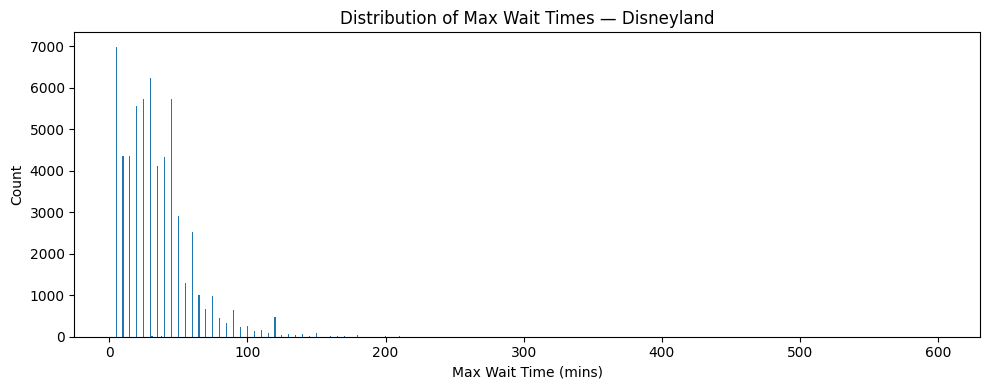

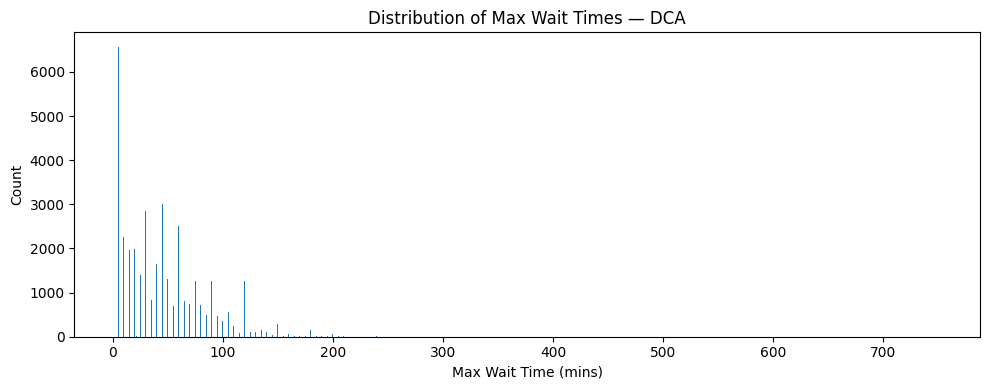

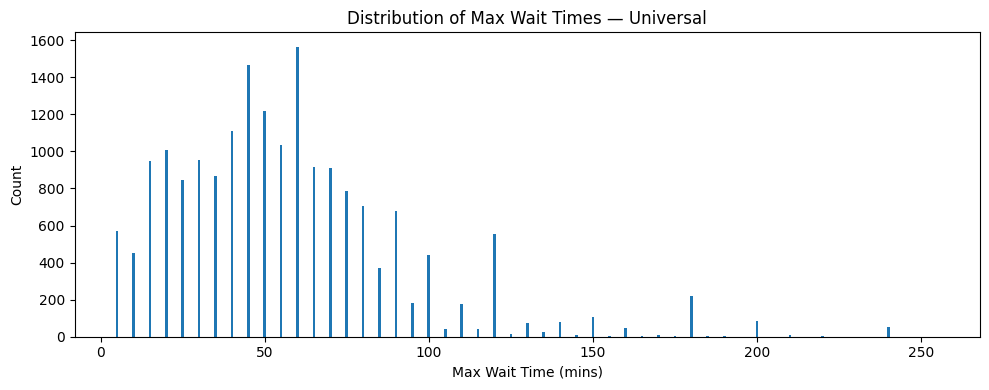

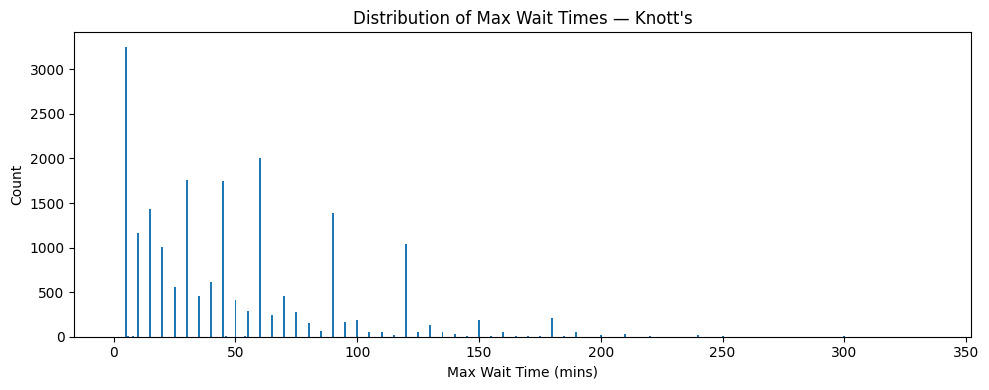

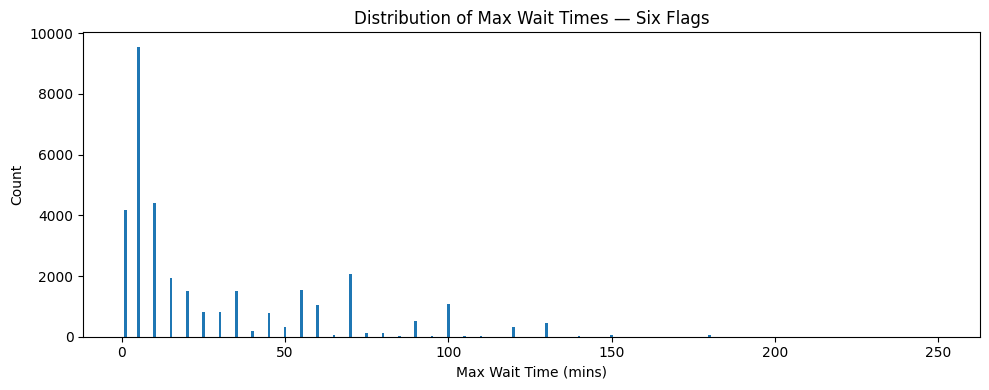

In [19]:

dfs_after = {
    "Disneyland": disney_df,
    "DCA": dca_df,
    "Universal": universal_df,
    "Knott's": knotts_df,
    "Six Flags": sixflags_df
}

for park, df in dfs_after.items():
    plt.figure(figsize=(10,4))

    # Count frequency of each max wait time value
    counts = df["Max Wait Time (mins)"].value_counts().sort_index()

    plt.bar(counts.index, counts.values)
    plt.title(f"Distribution of Max Wait Times — {park}")
    plt.xlabel("Max Wait Time (mins)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### Concluding Remarks on Exploratory Data Analysis

With all major cleaning steps completed and the distributions of wait times visually inspected, we have reached a solid stopping point for our exploratory data analysis. We began by identifying structural inconsistencies in ride names, removing non-ride entries, and standardizing labels across all parks. From there, we addressed missing values, investigated suspicious zero wait times, and removed placeholder or system-default maximum wait time values that would have distorted our results.

Through descriptive statistics and visualizations, we confirmed that the remaining wait time data is both realistic and representative of actual park operations. This cleaned and validated dataset now provides a reliable foundation for the next phase of our project, where we will shift from exploration to **statistical inference**, examining how long it takes for new rides to stabilize and modeling wait-time behavior across different theme parks.

EDA has given us clarity, confidence, and direction—ensuring that all further analysis is grounded in accurate and meaningful data.


### Combining All Parks Into a Single Dataset

To streamline our analysis and enable direct comparisons across parks, we combined all five cleaned datasets into one unified dataframe. Each entry now includes a new **"Park"** column that identifies whether the ride belongs to Disneyland, DCA, Universal Studios Hollywood, Knott’s Berry Farm, or Six Flags Magic Mountain. This consolidated structure allows us to compute metrics like relative IQR, stability thresholds, and cross-park summaries in a consistent and efficient way.


In [20]:
# Add park labels
disney_df_labeled    = disney_df.copy()
dca_df_labeled       = dca_df.copy()
universal_df_labeled = universal_df.copy()
knotts_df_labeled    = knotts_df.copy()
sixflags_df_labeled  = sixflags_df.copy()

disney_df_labeled["Park"]    = "Disneyland"
dca_df_labeled["Park"]       = "DCA"
universal_df_labeled["Park"] = "Universal Studios Hollywood"
knotts_df_labeled["Park"]    = "Knott's Berry Farm"
sixflags_df_labeled["Park"]  = "Six Flags Magic Mountain"

# Combine into one big dataframe
all_parks_df = pd.concat([
    disney_df_labeled,
    dca_df_labeled,
    universal_df_labeled,
    knotts_df_labeled,
    sixflags_df_labeled
], ignore_index=True)

# Display the first few rows
all_parks_df.head()


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins),Park
0,2015-01-01,Space Mountain,50.0,96.0,Disneyland
1,2015-01-01,Peter Pan's Flight,42.0,50.0,Disneyland
2,2015-01-01,Alice in Wonderland,37.0,50.0,Disneyland
3,2015-01-01,Roger Rabbit's Car Toon Spin,34.0,61.0,Disneyland
4,2015-01-01,Pirates of the Caribbean,28.0,60.0,Disneyland


### Using Old Rides to Define Stability and New Rides to Measure Time-to-Stability

Since our goal is to understand **how long it takes a new attraction to reach stable wait-time behavior**, we separated the dataset into two groups: established rides and newly added rides. The established rides provide a strong foundation for defining what “stable” means in practice, because they have long operational histories and well-formed wait-time patterns. Using these older rides, we can compute baseline stability metrics such as relative IQR thresholds.

Once this stability definition is established, we will apply it to the **newer rides**. These attractions are reserved specifically for testing how long it takes after opening for their wait times to settle into the stable range. This approach allows us to build a predictive framework based on historical patterns while evaluating model performance on rides that have undergone real-world early-operation volatility.


In [21]:
# ===== 1. DEFINE THE LIST OF NEW / RECENT RIDES (2015–2025) =====

new_rides_list = [
    # Disneyland & DCA
    "Millennium Falcon: Smugglers Run",
    "Star Wars: Rise of the Resistance",
    "Mickey & Minnie's Runaway Railway",
    "Guardians of the Galaxy – Mission: BREAKOUT!",
    "WEB SLINGERS: A Spider-Man Adventure",

    # Universal Studios Hollywood
    "Mario Kart: Bowser’s Challenge",
    "Flight of the Hippogriff",
    "Studio Tour",  # where the Fast & Furious: Supercharged finale exists

    # Knott's Berry Farm
    "Mystic Manor",               # you may remove this — it's not actually at Knott’s
    "GhostRider",
    "Calico River Rapids",
    "Voyage to the Iron Reef",

    # Six Flags Magic Mountain
    "West Coast Racers",
    "TEEN TITANS Turbo Spin",
    "Canyon Blaster",
]

# ===== 2. SPLIT THE FULL CLEANED DATASET =====
# all_parks_df must be:
# - fully cleaned (correct rides)
# - NaNs removed
# - zero-waits handled
# - default max-wait rows removed
# - park column included

new_rides_df = all_parks_df[all_parks_df["Ride"].isin(new_rides_list)].copy()
old_rides_df = all_parks_df[~all_parks_df["Ride"].isin(new_rides_list)].copy()

# ===== 3. DISPLAY BASIC INFO =====

print("New rides df shape:", new_rides_df.shape)
print("Old rides df shape:", old_rides_df.shape)

print("\n=== NEW RIDES (HEAD) ===")
display(new_rides_df.head())

print("\n=== OLD RIDES (HEAD) ===")
display(old_rides_df.head())


New rides df shape: (15098, 5)
Old rides df shape: (153645, 5)

=== NEW RIDES (HEAD) ===


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins),Park
31624,2019-05-20,Millennium Falcon: Smugglers Run,25.0,60.0,Disneyland
31644,2019-05-21,Millennium Falcon: Smugglers Run,23.0,45.0,Disneyland
31661,2019-05-22,Millennium Falcon: Smugglers Run,29.0,45.0,Disneyland
31696,2019-05-23,Millennium Falcon: Smugglers Run,5.0,5.0,Disneyland
31700,2019-05-24,Millennium Falcon: Smugglers Run,31.0,90.0,Disneyland



=== OLD RIDES (HEAD) ===


,Date,Ride,Average Wait Time (mins),Max Wait Time (mins),Park
0,2015-01-01,Space Mountain,50.0,96.0,Disneyland
1,2015-01-01,Peter Pan's Flight,42.0,50.0,Disneyland
2,2015-01-01,Alice in Wonderland,37.0,50.0,Disneyland
3,2015-01-01,Roger Rabbit's Car Toon Spin,34.0,61.0,Disneyland
4,2015-01-01,Pirates of the Caribbean,28.0,60.0,Disneyland


### Transitioning to Predictive Modeling: Defining Ride Stabilization Through Relative IQR

With our datasets fully cleaned and validated, we can now move toward the core analytical goal of the project: **predicting when a new ride stabilizes**. To do this, we need a quantitative definition of what “stability” means for theme-park wait times.

A natural way to measure stability is through the **Interquartile Range (IQR)** of a ride’s wait times. The IQR captures the middle 50% of the data and reflects how much the wait time fluctuates on a typical day. However, different rides operate on very different wait-time scales. A 5-minute variation is small for a ride that averages 90 minutes, but significant for a ride that averages 15 minutes.

To make our measure comparable across rides, we define stability using a **relative IQR**, expressed as a percentage of a ride’s typical wait time:

$$
\text{Relative IQR} = \frac{\text{IQR}}{\text{Median Wait Time}} \times 100
$$

This percentage-based approach ensures that shorter rides with naturally tight wait-time ranges are not unfairly penalized, while longer-wait rides are judged proportionally. A ride is considered *stable* once its daily relative IQR falls below a chosen percentage threshold for a consistent period of time.

This framework allows us to objectively determine how long each ride takes to reach operational stability and compare stabilization patterns across parks.


In [22]:


def compute_relative_iqr(df, wait_col="Average Wait Time (mins)"):
    g = df.groupby(["Park", "Ride"])[wait_col]

    med = g.median()
    q1 = g.quantile(0.25)
    q3 = g.quantile(0.75)

    iqr = q3 - q1
    rel_iqr = (iqr / med) * 100

    return (
        pd.DataFrame({
            "Median Wait": med,
            "IQR": iqr,
            "Relative IQR (%)": rel_iqr
        })
        .reset_index()
    )


all_parks_df = pd.concat(
    [
        disney_df.assign(Park="Disneyland"),
        dca_df.assign(Park="DCA"),
        universal_df.assign(Park="Universal"),
        knotts_df.assign(Park="Knott's"),
        sixflags_df.assign(Park="Six Flags"),
    ],
    ignore_index=True
)

print(old_rides_df.head()
)
new_rides_df = all_parks_df[all_parks_df["Ride"].isin(new_rides_list)].copy()
old_rides_df = all_parks_df[~all_parks_df["Ride"].isin(new_rides_list)].copy()

old_rides_iqr_df = compute_relative_iqr(old_rides_df)
old_rides_iqr_df = old_rides_iqr_df.sort_values("Relative IQR (%)")

display(old_rides_iqr_df.head())
display(old_rides_iqr_df.tail())


         Date                          Ride  Average Wait Time (mins)  \
0  2015-01-01                Space Mountain                      50.0   
1  2015-01-01            Peter Pan's Flight                      42.0   
2  2015-01-01           Alice in Wonderland                      37.0   
3  2015-01-01  Roger Rabbit's Car Toon Spin                      34.0   
4  2015-01-01      Pirates of the Caribbean                      28.0   

   Max Wait Time (mins)        Park  
0                  96.0  Disneyland  
1                  50.0  Disneyland  
2                  50.0  Disneyland  
3                  61.0  Disneyland  
4                  60.0  Disneyland  


,Park,Ride,Median Wait,IQR,Relative IQR (%)
5,DCA,Jessie’s Critter Carousel,5.0,0.00,0.000000
27,Disneyland,Mark Twain Riverboat,10.0,0.00,0.000000
34,Disneyland,Sailing Ship Columbia,10.0,1.00,10.000000
20,Disneyland,Davy Crockett's Explorer Canoes,10.0,3.00,30.000000
39,Disneyland,Tiana's Bayou Adventure,38.5,11.75,30.519481


,Park,Ride,Median Wait,IQR,Relative IQR (%)
48,Knott's,Supreme Scream,10.0,15.0,150.000000
56,Six Flags,Goliath,24.0,36.0,150.000000
46,Knott's,Silver Bullet,18.0,32.0,177.777778
62,Six Flags,Scream!,10.0,20.0,200.000000
60,Six Flags,Ninja,15.0,31.0,206.666667


### Removing Zero-Variance Rides from the Stability Baseline

When computing stability metrics for established rides, we identified a subset of attractions whose **relative IQR was exactly 0%**. This indicates that their recorded wait times showed **no variation at all** within the cleaned dataset—Q1, Q3, and the median were identical.

Such cases typically arise when:

- The ride only appeared in the dataset a few times,
- The recorded wait time was always the same value,
- Or the attraction experienced temporary closure or nonstandard reporting behavior.

Because these rides do not provide meaningful information about natural wait-time fluctuations, including them would artificially distort our definition of stability. To ensure our stability threshold is based on real operational behavior, we removed all rides with a **relative IQR of 0%** from the analysis.


In [23]:
# Drop rides where Relative IQR is exactly 0 or NaN
old_rides_iqr_df_filtered = old_rides_iqr_df[
    (old_rides_iqr_df["Relative IQR (%)"].notna()) &
    (old_rides_iqr_df["Relative IQR (%)"] != 0)
].copy()

print("Original number of rides:", len(old_rides_iqr_df))
print("After filtering zero-relative-IQR:", len(old_rides_iqr_df_filtered))

display(old_rides_iqr_df_filtered.head())


Original number of rides: 76
After filtering zero-relative-IQR: 74


,Park,Ride,Median Wait,IQR,Relative IQR (%)
34,Disneyland,Sailing Ship Columbia,10.0,1.00,10.000000
20,Disneyland,Davy Crockett's Explorer Canoes,10.0,3.00,30.000000
39,Disneyland,Tiana's Bayou Adventure,38.5,11.75,30.519481
30,Disneyland,Peter Pan's Flight,34.0,11.00,32.352941
9,DCA,Radiator Springs Racers,73.0,25.00,34.246575


### Establishing a Stability Threshold Using Relative IQR

With the zero-variance rides removed, we now analyzed the distribution of **relative IQR values** across all established rides. The goal of this step is to understand what typical wait-time fluctuations look like for rides that have been operating for many years. By computing descriptive statistics—such as the mean, median, standard deviation, and key percentiles—we gain insight into the natural variability of stable attractions.

This analysis allows us to identify a reasonable cutoff for what should be considered *stable* behavior. For example, rides with a relative IQR near the lower end of the distribution show very consistent wait times, while rides near the upper end are more volatile. Using measures like the median or a combination of the median and standard deviation gives us a principled way to define a stability threshold that reflects real operational patterns across parks.

This threshold will serve as the benchmark that we apply to **new rides** to determine how long after opening they reach stable, predictable wait-time behavior.


In [24]:
# Extract the relative IQR values
rel_iqr_values = old_rides_iqr_df_filtered["Relative IQR (%)"]

# Basic statistics
mean_rel_iqr = rel_iqr_values.mean()
median_rel_iqr = rel_iqr_values.median()
std_rel_iqr = rel_iqr_values.std()

# Percentiles
p25 = rel_iqr_values.quantile(0.25)
p50 = rel_iqr_values.quantile(0.50)
p75 = rel_iqr_values.quantile(0.75)

print("===== Relative IQR Summary for OLD RIDES =====")
print(f"Mean Relative IQR:   {mean_rel_iqr:.2f}%")
print(f"Median Relative IQR: {median_rel_iqr:.2f}%")
print(f"Std Dev:             {std_rel_iqr:.2f}%")
print()
print(f"25th Percentile:     {p25:.2f}%")
print(f"50th Percentile:     {p50:.2f}%")
print(f"75th Percentile:     {p75:.2f}%")

# A suggested stability threshold (example: median + 1 std)
suggested_threshold = median_rel_iqr + std_rel_iqr
print()
print(f"Suggested Stability Threshold: {suggested_threshold:.2f}%")


===== Relative IQR Summary for OLD RIDES =====
Mean Relative IQR:   84.51%
Median Relative IQR: 80.00%
Std Dev:             40.86%

25th Percentile:     54.38%
50th Percentile:     80.00%
75th Percentile:     109.58%

Suggested Stability Threshold: 120.86%


### Summarizing Relative IQR to Establish a Baseline for Stability

To understand typical wait-time fluctuations for established rides, we began by computing descriptive statistics for the relative IQR distribution. These measures—mean, median, standard deviation, and key percentiles—provide insight into the natural variability present across long-operating attractions.

The median and percentiles reveal where most rides cluster in terms of stability, while the mean and standard deviation describe the overall spread of the distribution. Together, these statistics help inform a reasonable threshold for what should be considered “stable” behavior before applying that threshold to new rides.


In [25]:

# Pull values from the filtered dataset
rel_values = old_rides_iqr_df_filtered["Relative IQR (%)"].dropna()

# Sample statistics
mean_val = rel_values.mean()
std_val = rel_values.std()
n = len(rel_values)

# Standard error
se = std_val / np.sqrt(n)

# 95% CI
lower_95 = mean_val - 1.96 * se
upper_95 = mean_val + 1.96 * se

print("===== 95% Confidence Interval for Mean Relative IQR =====")
print(f"Mean Relative IQR: {mean_val:.4f}%")
print(f"Standard Error:    {se:.4f}")
print(f"95% CI: [{lower_95:.4f}%, {upper_95:.4f}%]")


===== 95% Confidence Interval for Mean Relative IQR =====
Mean Relative IQR: 84.5126%
Standard Error:    4.7503
95% CI: [75.2021%, 93.8231%]


### 95% Prediction Interval: Understanding Individual Ride Variability

While confidence intervals describe uncertainty around the *mean* stability level, a prediction interval estimates where the **relative IQR of an individual ride** is likely to fall. This is especially useful in our context, because each ride behaves differently and may have its own natural level of volatility.

By constructing a 95% prediction interval, we capture the range in which a typical established ride’s relative IQR is expected to lie. Rides that fall far outside this interval can be interpreted as unusually stable or unusually volatile, giving us a more nuanced understanding of ride-level behavior.


In [26]:
# 95% Prediction Interval (for individual ride stability)
rel = old_rides_iqr_df_filtered["Relative IQR (%)"].dropna()

mean_rel = rel.mean()
std_rel = rel.std()

lower_pred_95 = mean_rel - 1.96 * std_rel
upper_pred_95 = mean_rel + 1.96 * std_rel

print("===== 95% Prediction Interval for Individual Ride Relative IQR =====")
print(f"Mean: {mean_rel:.4f}%")
print(f"Std Dev: {std_rel:.4f}%")
print(f"Prediction Interval: [{lower_pred_95:.4f}%, {upper_pred_95:.4f}%]")


===== 95% Prediction Interval for Individual Ride Relative IQR =====
Mean: 84.5126%
Std Dev: 40.8634%
Prediction Interval: [4.4203%, 164.6049%]


### Bootstrapped Confidence Interval: A Robust Alternative

Because relative IQR values may not follow a perfectly normal distribution—and can be skewed depending on ride types and park operations—we also created a **bootstrapped confidence interval**. This method repeatedly resamples the observed data to approximate the sampling distribution of the mean.

Unlike the traditional formula-based confidence interval, the bootstrap does not rely on normality assumptions. As a result, it provides a more reliable estimate of the true mean relative IQR, especially when dealing with complex or non-symmetric data. This makes it a valuable complement to the classical 95% confidence interval.


In [27]:
rel = old_rides_iqr_df_filtered["Relative IQR (%)"].dropna().values

# bootstrap parameters
boot_samples = 5000
boot_means = []

np.random.seed(42)

for _ in range(boot_samples):
    sample = np.random.choice(rel, size=len(rel), replace=True)
    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

lower_boot = np.percentile(boot_means, 2.5)
upper_boot = np.percentile(boot_means, 97.5)

print("===== Bootstrapped 95% Confidence Interval for Mean Relative IQR =====")
print(f"Bootstrap Mean: {boot_means.mean():.4f}%")
print(f"95% CI: [{lower_boot:.4f}%, {upper_boot:.4f}%]")


===== Bootstrapped 95% Confidence Interval for Mean Relative IQR =====
Bootstrap Mean: 84.3788%
95% CI: [75.5837%, 93.7075%]


### Visualizing the Relative IQR Distribution With Confidence Bounds

To better interpret the statistical results, we plotted the full distribution of relative IQR values and overlaid key reference lines: the mean, the 95% confidence interval, and the 95% prediction interval. This visualization makes it easier to see how established rides cluster in terms of stability and whether the distribution is symmetric, skewed, or heavy-tailed.

By examining the density curve alongside the statistical intervals, we gain a clearer picture of where typical stability lies and how much variation exists across rides. This graphical perspective helps validate the thresholds we will later apply when analyzing the stabilization of new attractions.


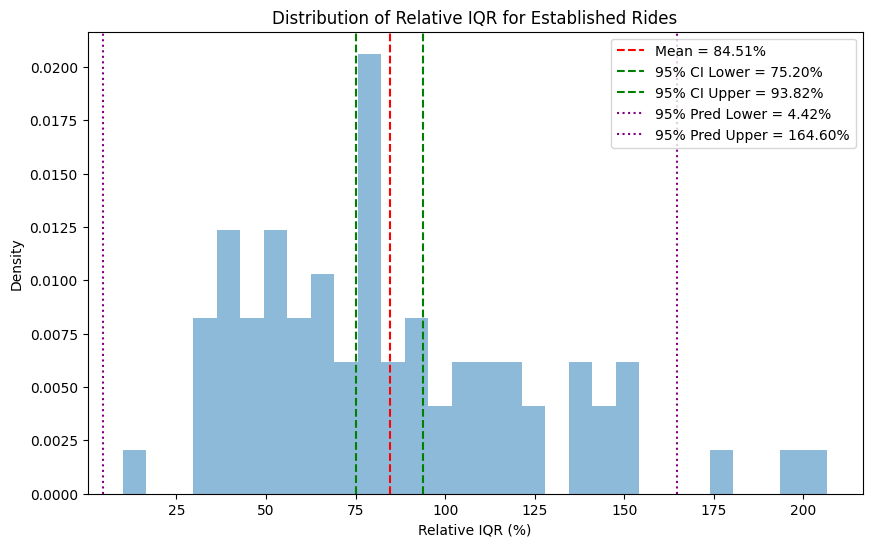

In [28]:


rel = old_rides_iqr_df_filtered["Relative IQR (%)"].dropna()

# compute stats again
mean_rel = rel.mean()
std_rel = rel.std()
n = len(rel)
se = std_rel / np.sqrt(n)

ci_lower = mean_rel - 1.96 * se
ci_upper = mean_rel + 1.96 * se

pred_lower = mean_rel - 1.96 * std_rel
pred_upper = mean_rel + 1.96 * std_rel

plt.figure(figsize=(10,6))

# density plot
plt.hist(rel, bins=30, density=True, alpha=0.5)
plt.title("Distribution of Relative IQR for Established Rides")

# plot mean
plt.axvline(mean_rel, color="red", linestyle="--", label=f"Mean = {mean_rel:.2f}%")

# plot 95% CI for mean
plt.axvline(ci_lower, color="green", linestyle="--", label=f"95% CI Lower = {ci_lower:.2f}%")
plt.axvline(ci_upper, color="green", linestyle="--", label=f"95% CI Upper = {ci_upper:.2f}%")

# plot 95% prediction interval
plt.axvline(pred_lower, color="purple", linestyle=":", label=f"95% Pred Lower = {pred_lower:.2f}%")
plt.axvline(pred_upper, color="purple", linestyle=":", label=f"95% Pred Upper = {pred_upper:.2f}%")

plt.xlabel("Relative IQR (%)")
plt.ylabel("Density")
plt.legend()
plt.show()


### Defining Stable Wait-Time Behavior Using Relative IQR

To develop a statistically grounded definition of “stable” wait-time behavior, we analyzed the **relative IQR** values for all established rides across the five parks. Because these rides have been operating for many years, their wait-time patterns serve as a reliable representation of long-term, steady-state behavior.

#### 1. Central Tendency and Overall Stability
Across all established rides, the **mean relative IQR** is approximately **84.5%**, with a standard error of about **4.75%**. This yields a **95% confidence interval ranging from 75.2% to 93.8%**, representing the plausible range where the *true average* ride stability lies. The narrowness of this interval indicates that, despite differences in parks and ride types, ride stability tends to cluster within a consistent band.

#### 2. Variability Across Individual Rides
We also computed a **95% prediction interval**, which reflects the range in which the relative IQR of an *individual ride* is likely to fall. This interval spans **4.4% to 164.6%**, illustrating the wide diversity in ride behavior—some rides are highly consistent, while others naturally fluctuate more due to popularity, capacity, or seasonal factors.

#### 3. Bootstrapped Confidence Interval for Robustness
Because relative IQR values are not guaranteed to follow a normal distribution, we constructed a **bootstrapped 95% confidence interval** for the mean. The bootstrap mean (84.38%) and interval (75.58%–93.71%) closely match the classical confidence interval, suggesting that our estimate of average stability is robust even under distributional skew.

#### 4. Visualization of the Relative IQR Distribution
A histogram of relative IQR values reveals:
- A strong concentration of values between **50% and 120%**
- A peak near the mean (~85%)
- A long tail extending toward higher variability
- Confidence and prediction interval markers that highlight where the majority of rides fall

This visualization reinforces the idea that while ride stability varies, it does so within a predictable and interpretable range.

---

### Final Definition of Stability

Taken together, these analyses allow us to define stability in a data-driven manner:

> A ride is considered **stable** when its daily relative IQR falls within the variability range typically exhibited by long-established attractions.

By using the empirical distribution of old rides as our reference, we can now examine **new rides** and measure **how long it takes after opening** for their wait-time behavior to fall within this stabilized range. This approach is park-agnostic, statistically justified, and grounded in real operational patterns.


### Measuring How Long New Rides Take to Reach Stable Wait-Time Behavior

With a data-driven stability definition established from long-running rides, the next major step in our analysis was to determine **how long it takes newly opened attractions to reach that same level of operational stability**. Because new rides often experience high demand, inconsistent throughput, technical adjustments, and preview periods, their wait-time patterns tend to fluctuate more widely in the early months after opening.

To measure this transition into stability, we aggregated each new ride’s wait times by **month**, computed the **relative IQR** for every month, and compared these values to the **stability band** derived from established rides (based on the 95% confidence interval of their relative IQR distribution). A ride is considered “stable” once its monthly relative IQR falls within this empirically determined band.

By identifying the **first month** in which a ride’s variability enters this stable range—and calculating the number of months between its opening date and that point—we obtain a quantitative estimate of **“months until stability.”**

This metric is crucial in the context of the project because it:

- Provides a standardized way to compare newly opened attractions across different parks.
- Captures real-world guest behavior and operational adjustments over time.
- Bridges historical operational patterns (old rides) with forward-looking predictions (new rides).
- Establishes a foundation for forecasting how soon future attractions might stabilize based on their early wait-time behavior.

In short, this step transforms qualitative expectations about new-ride volatility into a measurable, comparable statistic that supports meaningful predictions and practical insights for theme-park operations.


In [29]:


# -------------------------------------------------------------------
# 1. Compute stability band from OLD rides (95% CI for mean Relative IQR)
# -------------------------------------------------------------------
rel_vals = old_rides_iqr_df_filtered["Relative IQR (%)"].dropna().values

mean_rel = rel_vals.mean()
std_rel = rel_vals.std(ddof=1)
n = len(rel_vals)
se_rel = std_rel / np.sqrt(n)
z_95 = 1.96

ci_low_rel = mean_rel - z_95 * se_rel
ci_high_rel = mean_rel + z_95 * se_rel

print("Stability band for Relative IQR (%):")
print(f"  Mean ≈ {mean_rel:.2f}%")
print(f"  95% CI: [{ci_low_rel:.2f}%, {ci_high_rel:.2f}%]")

stability_low = ci_low_rel
stability_high = ci_high_rel

# -------------------------------------------------------------------
# 2. Prepare NEW rides df (ensure Date + Month exist)
# -------------------------------------------------------------------
df_new = new_rides_df.copy()
df_new["Date"] = pd.to_datetime(df_new["Date"])
df_new["Month"] = df_new["Date"].dt.to_period("M")  # e.g. 2019-05

# -------------------------------------------------------------------
# 3. Helper: compute monthly Relative IQR for one (Park, Ride) group
# -------------------------------------------------------------------
def compute_monthly_rel_iqr(group):
    monthly = (
        group
        .groupby("Month")["Average Wait Time (mins)"]
        .agg(
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            median="median"
        )
    )
    monthly["IQR"] = monthly["q3"] - monthly["q1"]
    monthly["Relative IQR (%)"] = np.where(
        monthly["median"] > 0,
        (monthly["IQR"] / monthly["median"]) * 100,
        np.nan
    )
    return monthly

# -------------------------------------------------------------------
# 4. For each new ride, compute months until stability
#    (using end-of-month and clamping to avoid negatives)
# -------------------------------------------------------------------
results = []

for (park, ride), grp in df_new.groupby(["Park", "Ride"]):
    grp = grp.sort_values("Date")
    opening_date = grp["Date"].min()

    monthly_stats = compute_monthly_rel_iqr(grp)

    # Months whose Relative IQR lies inside the stability band
    stable_months = monthly_stats[
        (monthly_stats["Relative IQR (%)"] >= stability_low) &
        (monthly_stats["Relative IQR (%)"] <= stability_high)
    ]

    if not stable_months.empty:
        first_stable_period = stable_months.index[0]  # a Period('YYYY-MM', 'M')

        # Use the END of that month as the "stability reached" marker
        first_stable_end = first_stable_period.to_timestamp(how="end")

        # Clamp so we never go earlier than opening_date
        if first_stable_end < opening_date:
            days_to_stable = 0
        else:
            days_to_stable = (first_stable_end - opening_date).days

        months_until_stability = round(days_to_stable / 30.44, 2)  # approx months
        reached_stability = True
        first_stable_str = str(first_stable_period)
    else:
        months_until_stability = np.nan
        reached_stability = False
        first_stable_str = None

    results.append({
        "Park": park,
        "Ride": ride,
        "Opening Date": opening_date,
        "First Stable Month": first_stable_str,
        "Months Until Stability (approx)": months_until_stability,
        "Reached Stability?": reached_stability
    })

new_rides_stability_df = pd.DataFrame(results)

display(new_rides_stability_df.sort_values(["Park", "Ride"]))


Stability band for Relative IQR (%):
  Mean ≈ 84.51%
  95% CI: [75.20%, 93.82%]


,Park,Ride,Opening Date,First Stable Month,Months Until Stability (approx),Reached Stability?
0,DCA,Guardians of the Galaxy – Mission: BREAKOUT!,2015-01-01,2023-02,97.90,True
1,DCA,WEB SLINGERS: A Spider-Man Adventure,2021-09-14,2023-05,20.50,True
2,Disneyland,Millennium Falcon: Smugglers Run,2019-05-20,2024-08,63.40,True
3,Disneyland,Star Wars: Rise of the Resistance,2021-11-22,None,NaN,False
4,Knott's,Calico River Rapids,2018-07-15,2019-12,17.54,True
5,Knott's,GhostRider,2018-07-15,2018-08,1.54,True
6,Six Flags,Canyon Blaster,2017-01-01,2017-01,0.99,True
7,Universal,Flight of the Hippogriff,2018-07-19,2019-03,8.38,True
8,Universal,Mario Kart: Bowser’s Challenge,2023-01-12,2023-11,10.58,True
9,Universal,Studio Tour,2018-07-19,2019-11,16.39,True


## 📘 Histogram of Old Ride Relative IQR with 95% CI

### *How stable are old rides?*

This histogram shows the distribution of **Relative IQR (%)** for all *old* rides.  
The dashed vertical lines represent the **95% confidence interval** for the mean Relative IQR, which defines the **stability band** used throughout the analysis.

**Why this matters:**  
Old rides represent mature wait-time behavior. Their typical variation establishes the benchmark for what “stable” looks like. A new ride is considered stable as soon as its Relative IQR enters this band.

This visualization answers:
- What typical variability looks like for mature rides  
- How wide or narrow the baseline stability window is  
- Why the CI is the correct choice for defining a stability benchmark  


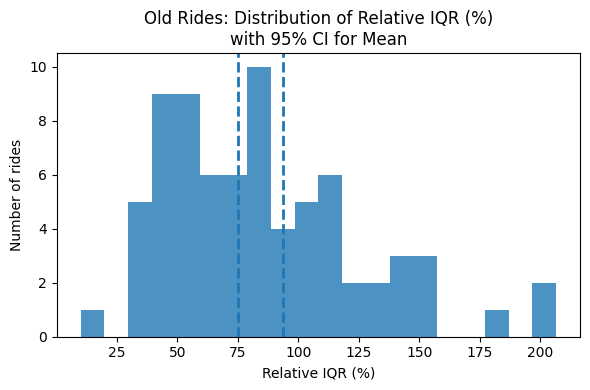

In [30]:

plt.figure(figsize=(6,4))
plt.hist(rel_vals, bins=20, alpha=0.8)
plt.axvline(ci_low_rel, linestyle="--", linewidth=2)
plt.axvline(ci_high_rel, linestyle="--", linewidth=2)
plt.xlabel("Relative IQR (%)")
plt.ylabel("Number of rides")
plt.title("Old Rides: Distribution of Relative IQR (%)\nwith 95% CI for Mean")
plt.tight_layout()
plt.show()


## 📘 Line Graph of a Single Ride with Shaded Stability Band

### *When does a specific ride settle into stable behavior?*

This visualization tracks a **single ride’s** Relative IQR (%) over time, plotted monthly.  
The shaded region represents the **stability band** derived from old rides’ 95% CI.

When the ride’s Relative IQR first enters this band—and stays there—it indicates that the ride has transitioned from early operational volatility to **stable, predictable wait-time behavior**.

This visualization highlights:
- The trajectory of variability after ride opening  
- The exact month of first stability  
- Whether stability was reached quickly or gradually  


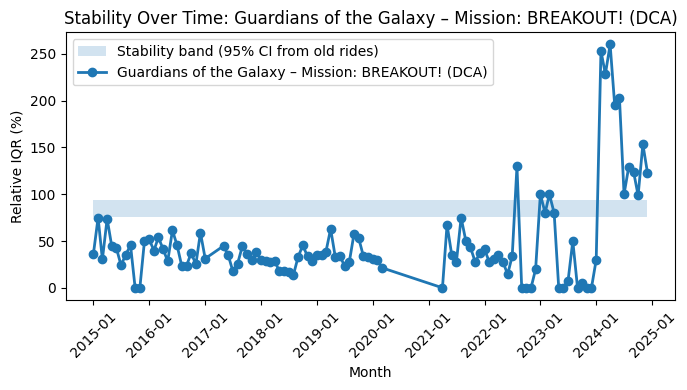

In [31]:

example = new_rides_stability_df.sort_values(
    "Months Until Stability (approx)", ascending=False
).iloc[0]

park_ex = example["Park"]
ride_ex = example["Ride"]

grp = df_new[(df_new["Park"] == park_ex) & (df_new["Ride"] == ride_ex)]
grp = grp.sort_values("Date")

monthly_stats = compute_monthly_rel_iqr(grp).reset_index()
monthly_stats["Month"] = monthly_stats["Month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(7,4))

ax.fill_between(
    monthly_stats["Month"],
    stability_low,
    stability_high,
    alpha=0.2,
    label="Stability band (95% CI from old rides)"
)

ax.plot(
    monthly_stats["Month"],
    monthly_stats["Relative IQR (%)"],
    marker="o",
    linewidth=2,
    label=f"{ride_ex} ({park_ex})"
)

ax.set_xlabel("Month")
ax.set_ylabel("Relative IQR (%)")
ax.set_title(f"Stability Over Time: {ride_ex} ({park_ex})")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


## 📘 Horizontal Bar Chart of Months Until Stability

### *Which rides stabilize the fastest? Which take the longest?*

This chart ranks all rides by their **Months Until Stability (approx)** value, sorted from fastest to slowest.

It provides instant insight into:
- Fast-stabilizing rides (usually simpler or high-capacity systems)  
- Slow-stabilizing rides (often complex, variable, or high-demand attractions)  
- Outliers that may signal unique operational patterns  

This visualization is ideal for comparing stability behavior across multiple rides and parks at a glance.


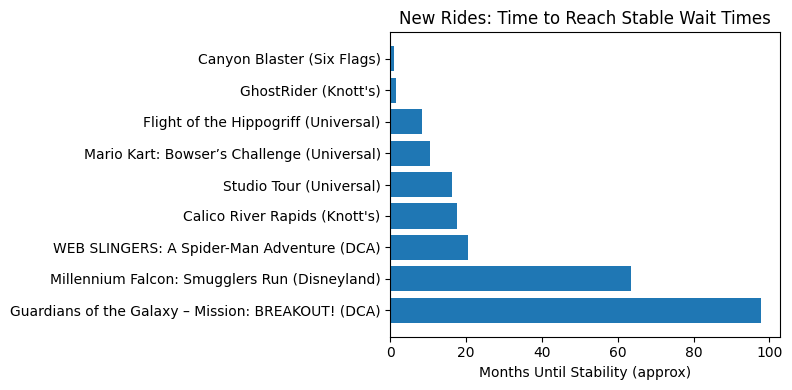

In [32]:
stable = new_rides_stability_df[new_rides_stability_df["Reached Stability?"]]

stable_sorted = stable.sort_values("Months Until Stability (approx)")

labels = stable_sorted["Ride"] + " (" + stable_sorted["Park"] + ")"
values = stable_sorted["Months Until Stability (approx)"]

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(stable_sorted))))

ax.barh(labels, values)
ax.set_xlabel("Months Until Stability (approx)")
ax.set_title("New Rides: Time to Reach Stable Wait Times")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 📘 Scatter Plot: Opening Date vs Months Until Stability

### *Are newer rides stabilizing faster or slower than older ones?*

This scatter plot maps each ride’s **Opening Date** to its **Months Until Stability**.

Rides that never reached stability within the dataset are plotted separately with distinct markers.

This visualization reveals:
- Whether stabilization time is improving for newer rides  
- Seasonal or year-related patterns in stabilization  
- Rides that fail to reach stability and may require further investigation  

It offers a time-based perspective on how operational maturity develops.


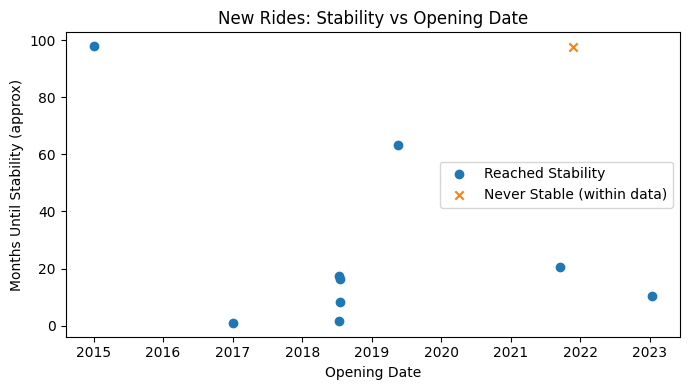

In [33]:
fig, ax = plt.subplots(figsize=(7,4))

mask_stable = new_rides_stability_df["Reached Stability?"]
stable_df = new_rides_stability_df[mask_stable]
unstable_df = new_rides_stability_df[~mask_stable]

ax.scatter(
    stable_df["Opening Date"],
    stable_df["Months Until Stability (approx)"],
    label="Reached Stability"
)

ax.scatter(
    unstable_df["Opening Date"],
    [ax.get_ylim()[1] * 0.95] * len(unstable_df),
    marker="x",
    label="Never Stable (within data)"
)

ax.set_xlabel("Opening Date")
ax.set_ylabel("Months Until Stability (approx)")
ax.set_title("New Rides: Stability vs Opening Date")
ax.legend()

plt.tight_layout()
plt.show()


## 📘 Heatmap of Time to Stability Across Ride × Park

### *How does stability time vary across parks and rides?*

This heatmap shows rides as rows and parks as columns, colored by the **months until stability**.

It highlights system-level patterns such as:
- Parks where rides consistently stabilize faster  
- Rides that are unusually slow to stabilize regardless of park  
- Missing or unstable cases that stand out visually  

This visualization provides a clean and comparative overview across the entire ride dataset.


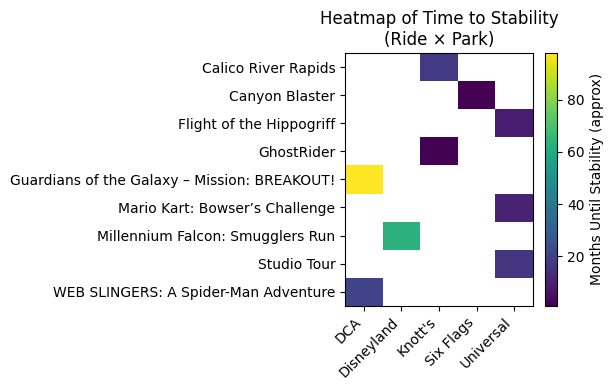

In [34]:
import numpy as np

stable = new_rides_stability_df[new_rides_stability_df["Reached Stability?"]]
pivot = stable.pivot(index="Ride", columns="Park", values="Months Until Stability (approx)")

fig, ax = plt.subplots(figsize=(6, max(4, 0.4 * pivot.shape[0])))

im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Months Until Stability (approx)")

ax.set_title("Heatmap of Time to Stability\n(Ride × Park)")
plt.tight_layout()
plt.show()


## Summary of Stability Analysis & Project Overview

### What We Accomplished
In this section of the project, we successfully determined **how long it takes for each new ride to reach a stable wait-time pattern**.  
We defined a ride as “stable” once its **Relative IQR (%)** fell inside the **stability band**, which was derived from the 95% confidence interval of mature (old) rides' variability.

This approach ensures that stability is not arbitrary—it is anchored to the real operational behavior of established attractions.

### Why the Five Visualizations Were Generated
The five graphs included above are not all required in the final deliverable.  
Rather, they serve as **exploratory visualization options**:

- To help us understand the data from multiple angles  
- To identify which plot best communicates the stabilization behavior  
- To offer flexibility depending on the style and story of your final report  

You may choose **one or two** that best support your narrative.  
The others simply help in sampling different perspectives.

### Full Project Summary
Across this notebook, the full workflow accomplishes:

1. **Historical EDA** — Understanding the long-term behavior of ride wait times and establishing benchmarks for variability.  
2. **Stability Band Construction** — Using old rides to compute a statistically grounded range of “normal” variability.  
3. **New Ride Time-to-Stability Analysis** — Measuring how long after opening each ride takes to reach mature, predictable behavioral patterns.  
4. **Visualization & Interpretation** — Building plots that make stabilization timelines intuitive, comparable, and data-driven.  

Together, these steps form a complete analysis pipeline that transitions from **raw operational data** to **insightful performance metrics** that parks could use operationally (e.g., forecasting, staffing, adjusting ride opening expectations, etc.).

